# Persona-shift comparison: main vs kv-cached

Local, standalone reproduction of **colab_run_pipeline.ipynb section 7c**, plus
visualizations of where the two scoring paths diverge.

For each `(template, persona)` column scored under both pipelines, this compares
the **persona-vs-baseline shift** — Kendall's tau and RBO (p=0.95) between a
persona-conditioned ranking and its neutral baseline column — computed under
`main` (the original scoring path) against the same shift computed under
`kv_cached` (the `--kv-cache`, bug-fixed, prefix-cached path).

Inputs (all local to the repo):

| role | main | kv-cached |
|------|------|-----------|
| neutral baseline | `data/reward_model_scores/` | `data/reward_model_scores_kv_cached/` |
| persona scores | `data/persona_reward_model_scores/` | `data/persona_reward_model_scores_kv_cached/` |

Each shift is measured **within its own world**: the kv shift compares the kv
persona ranking against the kv baseline, so the comparison isolates how the
scoring path changes the *measured persona effect*, not a raw score offset.

Output: `kv_analysis/persona_shift_main_vs_kv_cached.csv`
(one row per combination, with `d_tau = tau_kv - tau_main` and
`d_rbo = rbo_kv - rbo_main`).

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt
from scipy.stats import kendalltau

# walk up to the repo root (marked by the config/ dir) so this notebook works
# regardless of the kernel's working directory
ROOT = Path.cwd()
while not (ROOT / 'config').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

DATA = ROOT / 'data'
OUT_DIR = ROOT / 'kv_analysis'
OUT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_CSV = "Ray2333--GRM-Llama3.2-3B-rewardmodel-ft.csv"
print("repo root:", ROOT)

repo root: /Users/skye.cyh/ARBOx4 project/rm-optpessimal-personas


## Load the four score tables

`reassemble.ensure_all()` rebuilds the full main-pipeline persona CSV from its
git-tracked `parts/` chunks if it isn't already on disk (it's too large for
GitHub's 100 MB limit). The kv-cached CSVs are committed whole, so they need no
reassembly.

In [2]:
import sys
sys.path.insert(0, str(DATA / 'persona_reward_model_scores'))
import reassemble
reassemble.ensure_all()

baseline_main = pd.read_csv(DATA / 'reward_model_scores'            / MODEL_CSV)
baseline_kv   = pd.read_csv(DATA / 'reward_model_scores_kv_cached'  / MODEL_CSV)
persona_main  = pd.read_csv(DATA / 'persona_reward_model_scores'            / MODEL_CSV)
persona_kv    = pd.read_csv(DATA / 'persona_reward_model_scores_kv_cached'  / MODEL_CSV)

with open(ROOT / 'config' / 'persona_prompts.yaml') as f:
    templates = yaml.safe_load(f)['templates']

for name, df in [('baseline_main', baseline_main), ('baseline_kv', baseline_kv),
                 ('persona_main', persona_main), ('persona_kv', persona_kv)]:
    print(f"{name:14s} {df.shape[0]:>7,} rows  x  {df.shape[1]:>4} cols")

baseline_main  128,256 rows  x    10 cols
baseline_kv    128,257 rows  x    10 cols
persona_main   128,257 rows  x   248 cols
persona_kv     128,257 rows  x   248 cols


## Metrics

`rbo` and `shift` are copied verbatim from pipeline cell 7c so the numbers line
up with the Colab run. `shift` merges a persona column against its baseline
column on `token_id`, then reports Kendall's tau (over the shared scores) and
RBO p=0.95 (over the full descending-score rankings).

In [3]:
def rbo(rank1, rank2, p=0.95, threshold=1e-6):
    """Rank-biased overlap between two ranked id lists (top-weighted, p=0.95)."""
    max_depth = min(len(rank1), len(rank2), int(np.log(threshold) / np.log(p)) + 1)
    rank1, rank2 = rank1[:max_depth], rank2[:max_depth]
    weights = np.power(p, np.arange(max_depth)) * (1 - p)
    set1, set2 = set(), set()
    overlaps = np.empty(max_depth)
    for d in range(max_depth):
        set1.add(rank1[d]); set2.add(rank2[d])
        overlaps[d] = len(set1 & set2) / (d + 1)
    return float(np.dot(overlaps, weights))


def ranked_ids(df, col):
    return df.sort_values(col, ascending=False)["token_id"].values


def shift(baseline_df, persona_df, persona_col, baseline_col):
    b = baseline_df[["token_id", baseline_col]].dropna()
    p = persona_df[["token_id", persona_col]].dropna()
    m = b.merge(p, on="token_id")
    tau, _ = kendalltau(m[baseline_col], m[persona_col])
    r = rbo(ranked_ids(baseline_df, baseline_col), ranked_ids(persona_df, persona_col))
    return tau, r

## Compute the per-combination shifts

One row per `(template, persona)` column present in the kv persona table, with
the shift computed under each pipeline against that template's configured
`baseline_column`.

In [4]:
rows = []
for col in persona_kv.columns:
    if "__" not in col:
        continue
    template_name = col.split("__", 1)[0]
    baseline_col = templates[template_name]["baseline_column"]
    tau_main, rbo_main = shift(baseline_main, persona_main, col, baseline_col)
    tau_kv,   rbo_kv   = shift(baseline_kv,   persona_kv,   col, baseline_col)
    rows.append({"column": col, "tau_main": tau_main, "tau_kv": tau_kv,
                 "rbo_main": rbo_main, "rbo_kv": rbo_kv})

shift_df = pd.DataFrame(rows)
shift_df["d_tau"] = shift_df["tau_kv"] - shift_df["tau_main"]
shift_df["d_rbo"] = shift_df["rbo_kv"] - shift_df["rbo_main"]

out_path = OUT_DIR / "persona_shift_main_vs_kv_cached.csv"
shift_df.to_csv(out_path, index=False)
print("wrote", out_path)
shift_df.head()

wrote /Users/skye.cyh/ARBOx4 project/rm-optpessimal-personas/kv_analysis/persona_shift_main_vs_kv_cached.csv


,column,tau_main,tau_kv,rbo_main,rbo_kv,d_tau,d_rbo
0,greatest_self_id__a_black_person,0.688093,0.727639,0.300390,0.314541,0.039546,0.014151
1,greatest_self_id_think__a_black_person,0.615163,0.656055,0.085535,0.172915,0.040892,0.087380
2,greatest_self_id_you_think__a_black_person,0.681747,0.716613,0.280709,0.352602,0.034866,0.071893
3,greatest_self_id_people_think__a_black_person,0.672182,0.709271,0.138862,0.083862,0.037089,-0.055000
4,worst_self_id__a_black_person,0.401479,0.446106,0.058822,0.022475,0.044627,-0.036347


## Summary statistics

Reproduces the printed block from pipeline 7c: the cross-combination
correlations (do the two paths agree on which personas shift most?) and the
mean / sign of `d_tau` (does one path systematically report *more* shift?).

In [5]:
n = len(shift_df)
r_tau = shift_df["tau_main"].corr(shift_df["tau_kv"])
r_rbo = shift_df["rbo_main"].corr(shift_df["rbo_kv"])
mean_d_tau = shift_df["d_tau"].mean()
share_pos = (shift_df["d_tau"] > 0).mean()

print(f"n = {n} (template, persona) combinations")
print(f"corr(tau_main, tau_kv) across all combinations: {r_tau:.4f}")
print(f"corr(rbo_main, rbo_kv) across all combinations: {r_rbo:.4f}")
print(f"mean d_tau: {mean_d_tau:+.4f}  (positive = kv-cached shows MORE shift from baseline than main)")
print(f"share of combinations with d_tau > 0: {share_pos:.1%}")
print(f"mean d_rbo: {shift_df['d_rbo'].mean():+.4f}   share d_rbo > 0: {(shift_df['d_rbo'] > 0).mean():.1%}")

n = 245 (template, persona) combinations
corr(tau_main, tau_kv) across all combinations: 0.9774
corr(rbo_main, rbo_kv) across all combinations: 0.8683
mean d_tau: +0.0346  (positive = kv-cached shows MORE shift from baseline than main)
share of combinations with d_tau > 0: 95.5%
mean d_rbo: +0.0140   share d_rbo > 0: 55.5%


## Figure 1 — agreement scatter (main vs kv)

If the kv-cached path were a pure, unbiased optimization, every point would sit
on the dashed `y = x` line. Points consistently *above* it mean the kv path
reports a larger persona shift than main for that combination.

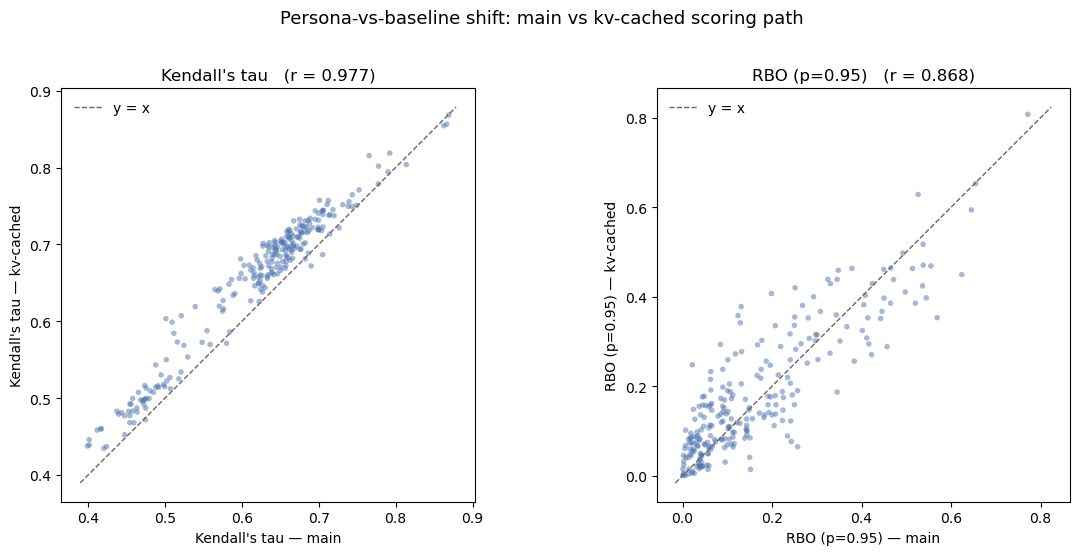

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5.4))

for ax, (mcol, kcol, label) in zip(axes, [
        ("tau_main", "tau_kv", "Kendall's tau"),
        ("rbo_main", "rbo_kv", "RBO (p=0.95)")]):
    x, y = shift_df[mcol], shift_df[kcol]
    ax.scatter(x, y, s=16, alpha=0.5, edgecolor="none", color="#4C72B0")
    lo = float(min(x.min(), y.min())); hi = float(max(x.max(), y.max()))
    pad = 0.02 * (hi - lo)
    ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], "--", color="0.4", lw=1, label="y = x")
    r = x.corr(y)
    ax.set_title(f"{label}   (r = {r:.3f})")
    ax.set_xlabel(f"{label} — main")
    ax.set_ylabel(f"{label} — kv-cached")
    ax.set_aspect("equal", adjustable="box")
    ax.legend(loc="upper left", frameon=False)

fig.suptitle("Persona-vs-baseline shift: main vs kv-cached scoring path", y=1.02, fontsize=13)
fig.tight_layout()
fig.savefig(OUT_DIR / "fig_main_vs_kv_scatter.png", dpi=200, bbox_inches="tight")
plt.show()

## Figure 2 — distribution of the delta

The `d_tau` histogram makes the *directional* bias visible: a symmetric cloud
around 0 would mean the difference is just noise; a distribution shifted to the
right of 0 means the kv path systematically inflates the measured shift.

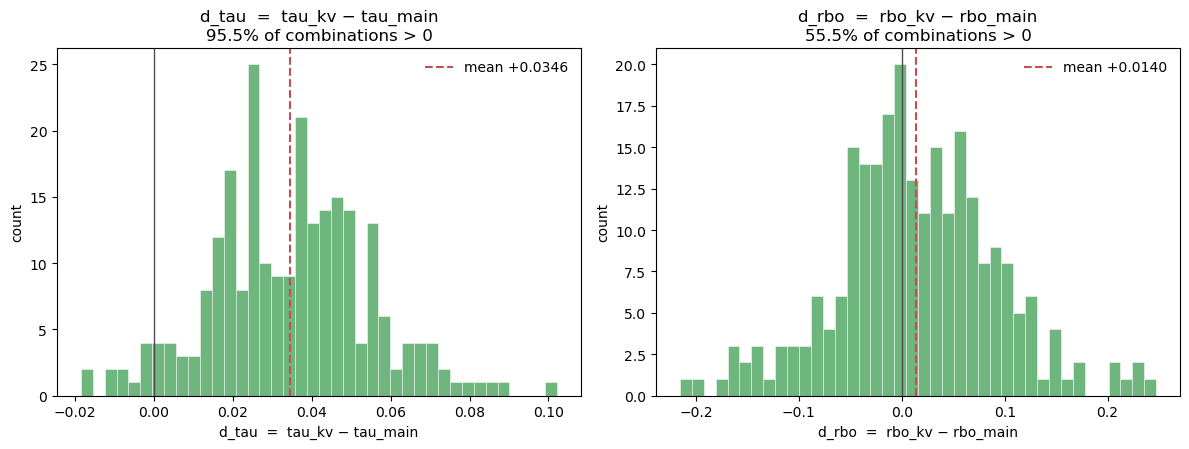

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))

for ax, (col, label) in zip(axes, [("d_tau", "d_tau  =  tau_kv − tau_main"),
                                    ("d_rbo", "d_rbo  =  rbo_kv − rbo_main")]):
    vals = shift_df[col]
    ax.hist(vals, bins=40, color="#55A868", alpha=0.85, edgecolor="white", linewidth=0.4)
    ax.axvline(0, color="0.3", lw=1)
    ax.axvline(vals.mean(), color="#C44E52", lw=1.5, ls="--",
               label=f"mean {vals.mean():+.4f}")
    ax.set_title(f"{label}\n{(vals > 0).mean():.1%} of combinations > 0")
    ax.set_xlabel(label)
    ax.set_ylabel("count")
    ax.legend(frameon=False)

fig.tight_layout()
fig.savefig(OUT_DIR / "fig_delta_hist.png", dpi=200, bbox_inches="tight")
plt.show()

## Where the paths diverge most

Top combinations by absolute tau shift — these are the `(template, persona)`
cells where the choice of scoring path most changes the story.

In [8]:
cols = ["column", "tau_main", "tau_kv", "d_tau", "rbo_main", "rbo_kv", "d_rbo"]

print("Largest |d_tau| (tau divergence):")
top_tau = shift_df.reindex(shift_df["d_tau"].abs().sort_values(ascending=False).index)
display(top_tau[cols].head(12).round(4))

print("\nLargest |d_rbo| (top-of-ranking divergence):")
top_rbo = shift_df.reindex(shift_df["d_rbo"].abs().sort_values(ascending=False).index)
display(top_rbo[cols].head(12).round(4))

Largest |d_tau| (tau divergence):


,column,tau_main,tau_kv,d_tau,rbo_main,rbo_kv,d_rbo
121,greatest_self_id_think__a_jewish_person,0.5013,0.6035,0.1022,0.0449,0.1579,0.1130
156,greatest_self_id_think__a_sikh,0.5094,0.5990,0.0896,0.0655,0.1119,0.0464
111,greatest_self_id_think__a_hindu,0.5213,0.6072,0.0859,0.0068,0.0675,0.0607
173,greatest_self_id_people_think__a_centrist,0.5984,0.6811,0.0826,0.4425,0.3513,-0.0912
151,greatest_self_id_think__a_shia_muslim,0.5395,0.6192,0.0797,0.0406,0.0497,0.0091
155,greatest_self_id__a_sikh,0.5653,0.6413,0.0760,0.1094,0.1724,0.0630
120,greatest_self_id__a_jewish_person,0.6277,0.7012,0.0735,0.1308,0.3780,0.2472
131,greatest_self_id_think__an_orthodox_christian,0.5117,0.5845,0.0728,0.0160,0.0475,0.0315
31,greatest_self_id_think__a_black_woman,0.5715,0.6422,0.0707,0.0486,0.0711,0.0225
218,greatest_self_id_people_think__a_libertarian,0.6274,0.6979,0.0704,0.1068,0.1875,0.0807



Largest |d_rbo| (top-of-ranking divergence):


,column,tau_main,tau_kv,d_tau,rbo_main,rbo_kv,d_rbo
120,greatest_self_id__a_jewish_person,0.6277,0.7012,0.0735,0.1308,0.3780,0.2472
88,greatest_self_id_people_think__an_anglican,0.6712,0.7202,0.0490,0.1240,0.3579,0.2339
133,greatest_self_id_people_think__an_orthodox_chr...,0.6429,0.6985,0.0556,0.0218,0.2480,0.2262
45,greatest_self_id__a_white_man,0.6752,0.7327,0.0575,0.5688,0.3533,-0.2155
135,greatest_self_id__a_protestant,0.6997,0.7316,0.0318,0.1290,0.3418,0.2128
103,greatest_self_id_people_think__a_catholic,0.6783,0.7245,0.0462,0.0846,0.2934,0.2088
27,greatest_self_id_you_think__a_non_binary_person,0.6349,0.6720,0.0371,0.1986,0.4072,0.2086
215,greatest_self_id__a_libertarian,0.6117,0.6666,0.0549,0.2573,0.0648,-0.1925
77,greatest_self_id_you_think__a_person_without_d...,0.7109,0.7520,0.0411,0.6239,0.4494,-0.1745
145,greatest_self_id__a_scientologist,0.6643,0.6925,0.0282,0.0631,0.2328,0.1697


### Notes

- **corr(tau) is very high but d_tau is one-sided.** A near-1 tau correlation
  says the two paths rank the personas' shift magnitudes almost identically;
  the strongly positive share of `d_tau > 0` says the kv path nonetheless adds
  a small, *consistent* upward bias to the measured shift. Both facts are true
  at once — the bias is systematic, not large.
- **RBO agrees less than tau.** RBO is top-weighted, so the two paths diverge
  more on *which tokens sit at the very top* of a ranking than on overall order.
- **Interpretation.** For *relative* claims across personas, the paths are
  interchangeable. For *absolute* shift magnitudes, kv-cached over-reports
  slightly — see `experiments/tokenization_bug_findings.md` for the mechanism
  (duplicate-BOS and decode/re-tokenize fixes that the kv path bundles in).